# 8.1. EEG CNN: Convolutional Neural Nets for Decoding

**Learning Objectives:**
- Understand how **convolutional neural networks (CNNs)** can be applied to EEG decoding
- Build a simple **end-to-end CNN** that operates directly on EEG epochs
- Learn how to prepare EEG data for **PyTorch** (tensors, shapes, batching)
- Implement **training, validation, and testing loops** with proper cross-validation
- Visualize **learning curves** and inspect model performance

**Key Concepts:**
- **End-to-End Learning**: Learning features and classifier jointly from raw/ minimally processed data
- **Convolution over Time / Channels**: 1D convolutions applied across time, optionally across sensors
- **Regularization**: Dropout, weight decay, and early stopping to prevent overfitting
- **Mini-batch Training**: Stochastic gradient descent with batches for scalability
- **GPU Acceleration**: Leveraging CUDA when available (optional)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mne
from mne.datasets import sample

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
mne.set_config('MNE_TQDM', 'off')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load and Prepare EEG/MEG Data

We follow the same preprocessing pipeline as in **7.1**:
- Load the **MNE sample** dataset
- Filter and pick **gradiometer** channels
- Epoch around stimuli and decode **auditory vs visual** conditions

This gives us data with shape `(n_trials, n_channels, n_times)` suitable for 1D CNNs.

In [ ]:
repo_root = Path("./").resolve().parents[1]
target_dir = repo_root / "datasets" / "meg_sample"
target_dir.mkdir(parents=True, exist_ok=True)

data_path = sample.data_path(path=str(target_dir), download=True)

meg_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
events_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw-eve.fif'

raw = mne.io.read_raw_fif(meg_file, preload=True)
events = mne.read_events(events_fname)

print(f"Loaded raw data with {len(raw.ch_names)} channels")
print(f"Found {len(events)} events")

Opening raw data file /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Loaded raw data with 376 channels
Found 320 events


In [3]:
# Basic preprocessing (as in 7.1)
raw.filter(l_freq=1.0, h_freq=40.0, n_jobs=1)
raw.pick_types(meg='grad', eeg=False, eog=False, stim=False)

print(f"Filtered data, {len(raw.ch_names)} gradiometer channels")

event_id_separate = {
    'auditory/left': 1,
    'auditory/right': 2,
    'visual/left': 3,
    'visual/right': 4,
}

tmin, tmax = -0.2, 0.5

epochs = mne.Epochs(
    raw,
    events,
    event_id_separate,
    tmin,
    tmax,
    baseline=(None, 0),
    preload=True,
    reject=dict(grad=4000e-13),
    decim=4,  # downsample for speed
)

# Binary labels: auditory (0) vs visual (1)
epochs.events[:, 2] = (epochs.events[:, 2] >= 3).astype(int)
epochs.event_id = {'auditory': 0, 'visual': 1}

X = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
y = epochs.events[:, 2]

print(f"Epochs shape: {X.shape}")
print(f"Class balance: auditory={np.sum(y==0)}, visual={np.sum(y==1)}")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtered data, 203 gradiometer channels
Not setting metadata
289 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 289 events and 421 original time points (prior to decimation) ...
0 bad epochs dropped
Epochs shape: (289, 203

## 2. Build a PyTorch Dataset and DataLoaders

We'll define a small `EEGDataset` to wrap the NumPy arrays and return PyTorch tensors.

For CNNs, we keep the data as `(batch, channels, time)` and apply 1D convolutions over time.

In [4]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = EEGDataset(X, y)
n_samples, n_channels, n_times = X.shape
print(f"Dataset size: {len(dataset)} trials")
print(f"Channels: {n_channels}, Time samples: {n_times}")

Dataset size: 289 trials
Channels: 203, Time samples: 106


## 3. Define a Simple 1D CNN Architecture

We'll implement a compact CNN:

- **Conv1** over time, with kernel size 7
- **BatchNorm + ReLU + MaxPool**
- **Conv2** over time
- Global average pooling over time
- Fully connected layer to 2 output classes

This is **not** an optimized architecture, but a minimal example showing how to connect EEG tensors to a CNN.

In [5]:
class SimpleEEGCNN(nn.Module):
    def __init__(self, n_channels, n_times, n_classes=2):
        super().__init__()
        
        self.conv1 = nn.Conv1d(in_channels=n_channels, out_channels=32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        # We'll use adaptive average pooling to collapse time dimension
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(p=0.5)
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):  # x: (batch, channels, time)
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        
        x = self.global_pool(x)  # (batch, 64, 1)
        x = x.squeeze(-1)        # (batch, 64)
        x = self.dropout(x)
        x = self.fc(x)
        return x


model = SimpleEEGCNN(n_channels=n_channels, n_times=n_times, n_classes=2).to(device)
print(model)

SimpleEEGCNN(
  (conv1): Conv1d(203, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


## 4. Training Loop with Train/Validation Split

To keep things simple and reasonably fast, we'll:

- Split the dataset into **train** (70%), **validation** (15%), and **test** (15%) sets
- Train for a small number of epochs (e.g., 15–20)
- Track **training** and **validation** loss/accuracy
- Evaluate **test accuracy** at the end

We could also wrap this into **cross-validation** over folds (as in 7.1/7.3), but here we focus on the
core deep learning mechanics.

In [6]:
batch_size = 32
n_epochs = 20
learning_rate = 1e-3

# Train/val/test split indices (stratified by label)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, temp_idx = next(skf.split(X, y))  # first fold as train vs temp
y_temp = y[temp_idx]

# Split temp into val/test
skf_temp = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
_temp_train, temp_val = next(skf_temp.split(np.zeros_like(y_temp), y_temp))
val_idx = temp_idx[temp_val]
test_idx = np.setdiff1d(temp_idx, val_idx)

print(f"Train trials: {len(train_idx)}")
print(f"Val trials:   {len(val_idx)}")
print(f"Test trials:  {len(test_idx)}")

train_ds = EEGDataset(X[train_idx], y[train_idx])
val_ds = EEGDataset(X[val_idx], y[val_idx])
test_ds = EEGDataset(X[test_idx], y[test_idx])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

Train trials: 231
Val trials:   29
Test trials:  29


In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return running_loss / total, correct / total

In [8]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_state_dict = None

for epoch in range(1, n_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = model.state_dict()

    print(f"Epoch {epoch:02d} | "
          f"Train loss: {train_loss:.3f}, acc: {train_acc:.3f} | "
          f"Val loss: {val_loss:.3f}, acc: {val_acc:.3f}")

# Restore best model
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"\nRestored best model with val acc = {best_val_acc:.3f}")

Epoch 01 | Train loss: 0.698, acc: 0.502 | Val loss: 0.694, acc: 0.517
Epoch 02 | Train loss: 0.698, acc: 0.502 | Val loss: 0.694, acc: 0.517
Epoch 03 | Train loss: 0.696, acc: 0.502 | Val loss: 0.694, acc: 0.517
Epoch 04 | Train loss: 0.696, acc: 0.502 | Val loss: 0.693, acc: 0.517
Epoch 05 | Train loss: 0.694, acc: 0.502 | Val loss: 0.693, acc: 0.517
Epoch 06 | Train loss: 0.694, acc: 0.506 | Val loss: 0.693, acc: 0.517
Epoch 07 | Train loss: 0.693, acc: 0.481 | Val loss: 0.693, acc: 0.517
Epoch 08 | Train loss: 0.694, acc: 0.459 | Val loss: 0.698, acc: 0.483
Epoch 09 | Train loss: 0.693, acc: 0.498 | Val loss: 0.698, acc: 0.483
Epoch 10 | Train loss: 0.695, acc: 0.468 | Val loss: 0.741, acc: 0.483
Epoch 11 | Train loss: 0.694, acc: 0.511 | Val loss: 0.730, acc: 0.483
Epoch 12 | Train loss: 0.693, acc: 0.502 | Val loss: 1.070, acc: 0.483
Epoch 13 | Train loss: 0.693, acc: 0.515 | Val loss: 2.049, acc: 0.483
Epoch 14 | Train loss: 0.692, acc: 0.576 | Val loss: 3.406, acc: 0.483
Epoch 

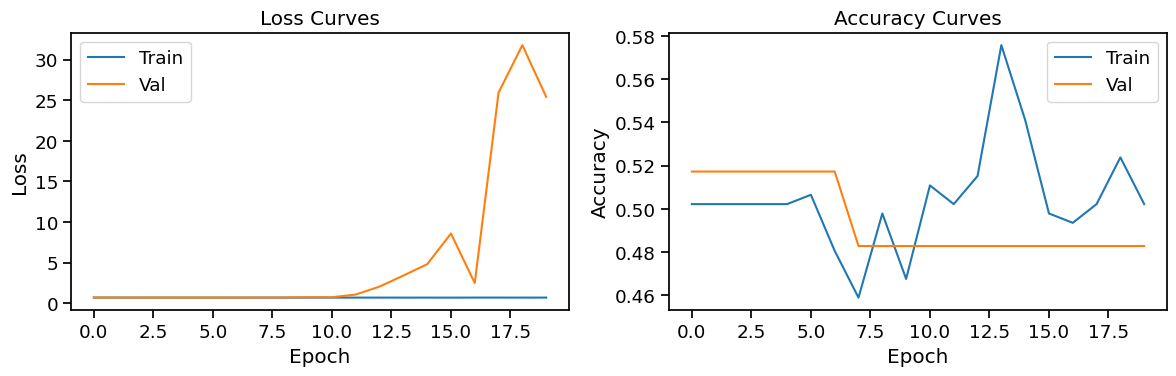

In [9]:
# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses, label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()

axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Test Set Evaluation

Finally, we evaluate the **held-out test set** that was never used during training or validation.

In [10]:
# Evaluate on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

# Collect predictions for confusion matrix
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

cm = confusion_matrix(all_true, all_preds)
print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(all_true, all_preds, target_names=['auditory', 'visual']))

Test loss: 23.720
Test accuracy: 0.517

Confusion matrix:
[[ 0 14]
 [ 0 15]]

Classification report:
              precision    recall  f1-score   support

    auditory       0.00      0.00      0.00        14
      visual       0.52      1.00      0.68        15

    accuracy                           0.52        29
   macro avg       0.26      0.50      0.34        29
weighted avg       0.27      0.52      0.35        29

